## Step 0: Import Libraries

In [1]:
import os
import numpy as np
import cv2
from pathlib import Path
from sklearn.model_selection import train_test_split
import json
from PIL import Image, ImageEnhance
import random

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## Step 1: Load Original Images (NO Augmentation Yet)

In [2]:
# Load original images from dataset_sungai/
dataset_path = Path('datasetScrap3')
output_path = Path('data_processed_original_only')

# Find all images recursively
image_files = list(dataset_path.glob('**/*.jpg')) + list(dataset_path.glob('**/*.png'))
print(f"Total images found: {len(image_files)}")

# Categorize images by label
image_paths = []

for img_file in sorted(image_files):
    parent_name = img_file.parent.name.lower()
    
    if 'jernih' in parent_name or 'clear' in parent_name:
        label = 0  # Clear
    elif 'keruh' in parent_name or 'turbid' in parent_name:
        label = 1  # Turbid
    else:
        if 'keruh' in img_file.name.lower():
            label = 1
        elif 'jernih' in img_file.name.lower():
            label = 0
        else:
            continue
    
    image_paths.append((str(img_file), label))

print(f"Images with labels: {len(image_paths)}")
clear_count = sum(1 for _, l in image_paths if l == 0)
turbid_count = sum(1 for _, l in image_paths if l == 1)
print(f"Class distribution - Clear: {clear_count}, Turbid: {turbid_count}")

Total images found: 807
Images with labels: 807
Class distribution - Clear: 480, Turbid: 327


## Step 2: Image Preprocessing Function

In [3]:
def preprocess_image(img_path, target_size=(224, 224)):
    """
    Load and preprocess image for ResNet18/XceptionNet
    
    Args:
        img_path: Path to image file
        target_size: Target size (224x224)
    
    Returns:
        np.array: Preprocessed image normalized to [0, 1]
    """
    img = cv2.imread(img_path)
    if img is None:
        return None
    
    # BGR -> RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize to 224x224
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_LINEAR)
    
    # Normalize to [0, 1]
    img = img.astype('float32') / 255.0
    
    return img

print("✅ Preprocessing function defined")

✅ Preprocessing function defined


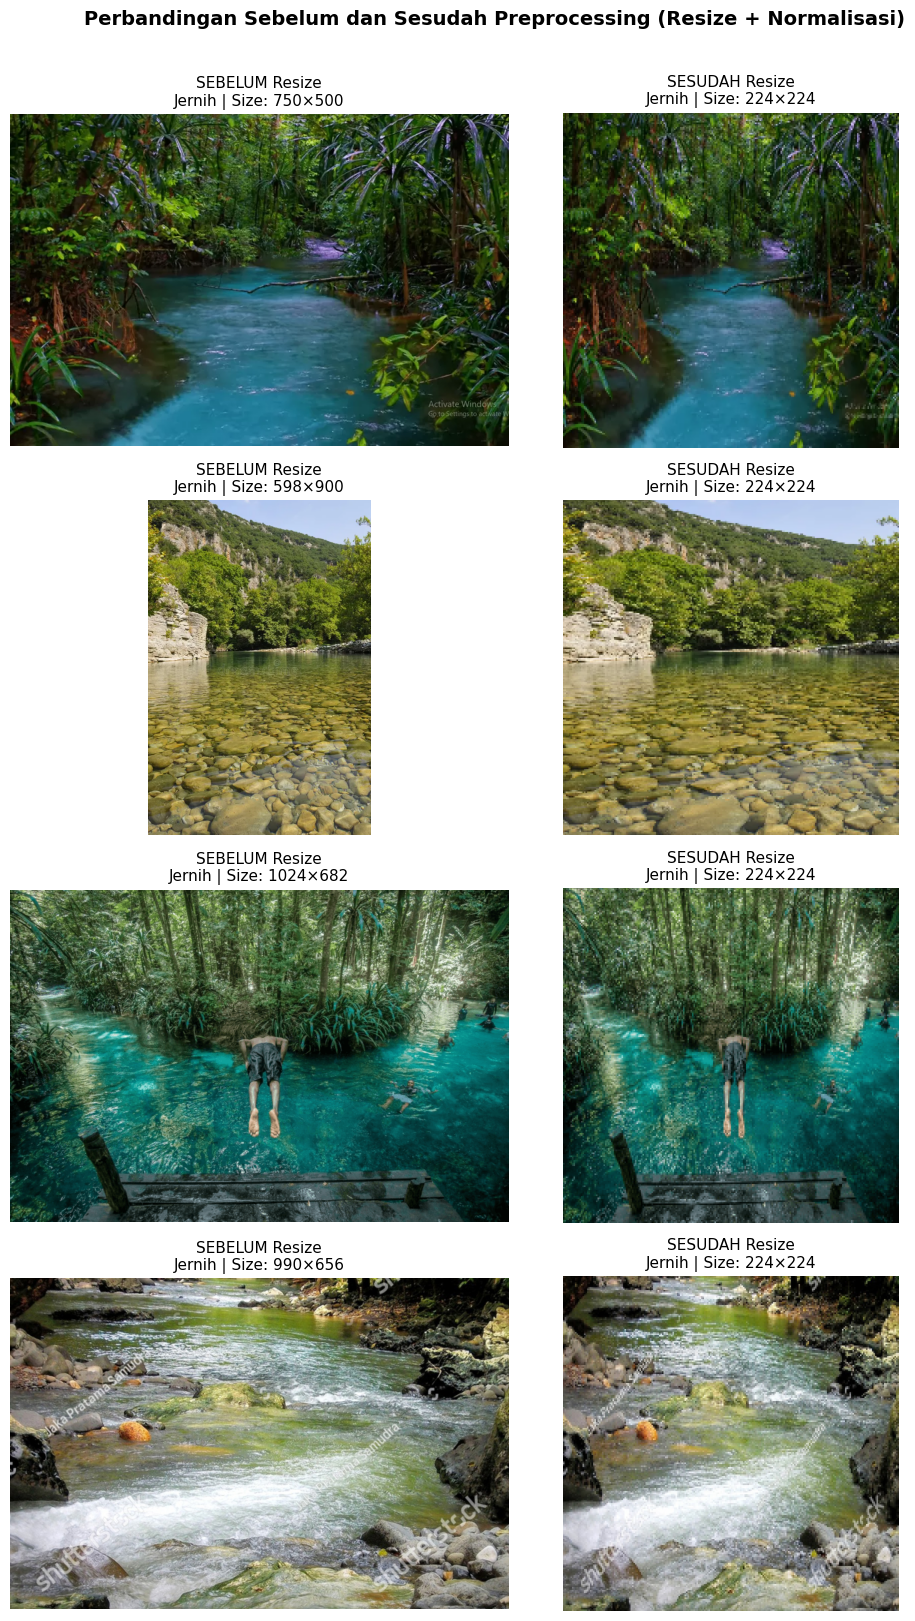

📊 Visualisasi disimpan: preprocessing_before_after.png


In [4]:
import matplotlib.pyplot as plt

# Ambil beberapa sampel gambar untuk visualisasi
sample_paths = [image_paths[i][0] for i in range(min(4, len(image_paths)))]
sample_labels = [image_paths[i][1] for i in range(min(4, len(image_paths)))]
label_names = {0: 'Jernih', 1: 'Keruh'}

fig, axes = plt.subplots(len(sample_paths), 2, figsize=(10, 4 * len(sample_paths)))

for i, (img_path, label) in enumerate(zip(sample_paths, sample_labels)):
    # ===== SEBELUM RESIZE (Original) =====
    img_original = cv2.imread(img_path)
    img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
    
    axes[i, 0].imshow(img_original)
    axes[i, 0].set_title(f"SEBELUM Resize\n{label_names[label]} | Size: {img_original.shape[1]}×{img_original.shape[0]}", fontsize=11)
    axes[i, 0].axis('off')
    
    # ===== SESUDAH RESIZE (224x224 + Normalized) =====
    img_resized = preprocess_image(img_path)
    
    axes[i, 1].imshow(img_resized)
    axes[i, 1].set_title(f"SESUDAH Resize\n{label_names[label]} | Size: 224×224", fontsize=11)
    axes[i, 1].axis('off')

plt.suptitle("Perbandingan Sebelum dan Sesudah Preprocessing (Resize + Normalisasi)", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('preprocessing_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"📊 Visualisasi disimpan: preprocessing_before_after.png")

## Step 3: Load All Images

In [5]:
# Load all images into memory
images = []
valid_labels = []
valid_paths = []
failed = 0

print(f"Loading {len(image_paths)} original images...")

for idx, (img_path, label) in enumerate(image_paths):
    if (idx + 1) % 50 == 0:
        print(f"  {idx + 1}/{len(image_paths)} loaded...")
    
    img = preprocess_image(img_path)
    if img is not None:
        images.append(img)
        valid_labels.append(label)
        valid_paths.append(img_path)
    else:
        failed += 1

# Convert to numpy arrays
X = np.array(images)
y = np.array(valid_labels)

print(f"\n✅ Loaded: {len(images)} images")
print(f"❌ Failed: {failed} images")
print(f"\nDataset shape: {X.shape}")
print(f"Value range: [{X.min():.3f}, {X.max():.3f}]")
print(f"Label distribution: Clear={np.sum(y==0)}, Turbid={np.sum(y==1)}")

Loading 807 original images...
  50/807 loaded...
  100/807 loaded...
  150/807 loaded...
  200/807 loaded...
  250/807 loaded...
  300/807 loaded...
  350/807 loaded...
  400/807 loaded...
  450/807 loaded...
  500/807 loaded...
  550/807 loaded...
  600/807 loaded...
  650/807 loaded...
  700/807 loaded...
  750/807 loaded...
  800/807 loaded...

✅ Loaded: 790 images
❌ Failed: 17 images

Dataset shape: (790, 224, 224, 3)
Value range: [0.000, 1.000]
Label distribution: Clear=480, Turbid=310


## Step 4: Split Dataset FIRST (70/15/15) - NO Augmentation Yet

In [7]:
# Split 1: 70% training, 30% temporary (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Split 2: 50/50 of temp -> 15% each for val & test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("✅ Dataset Split Complete (NO Augmentation Applied Yet)")
print(f"\nTrain set: {X_train.shape[0]} images (Clear={np.sum(y_train==0)}, Turbid={np.sum(y_train==1)})")
print(f"Val set:   {X_val.shape[0]} images (Clear={np.sum(y_val==0)}, Turbid={np.sum(y_val==1)})")
print(f"Test set:  {X_test.shape[0]} images (Clear={np.sum(y_test==0)}, Turbid={np.sum(y_test==1)})")
print(f"\nTotal: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} images")
print(f"\n📌 IMPORTANT: Val & Test sets are ORIGINAL (not augmented) for true evaluation!")

✅ Dataset Split Complete (NO Augmentation Applied Yet)

Train set: 553 images (Clear=336, Turbid=217)
Val set:   118 images (Clear=72, Turbid=46)
Test set:  119 images (Clear=72, Turbid=47)

Total: 790 images

📌 IMPORTANT: Val & Test sets are ORIGINAL (not augmented) for true evaluation!


## Step 5: Keep Training Set ORIGINAL (No Augmentation)

In [8]:
# Define simple augmentation functions (optional, not applied in this run)
def random_rotate(img, angle_range=15):
    """Rotate image by random angle"""
    angle = random.randint(-angle_range, angle_range)
    rows, cols = img.shape[:2]
    rotation_matrix = cv2.getRotationMatrix2D((cols / 2, rows / 2), angle, 1)
    return cv2.warpAffine(img, rotation_matrix, (cols, rows))

def random_flip(img):
    """Randomly flip image horizontally or vertically"""
    if random.random() > 0.5:
        img = cv2.flip(img, 1)  # Horizontal flip
    if random.random() > 0.5:
        img = cv2.flip(img, 0)  # Vertical flip
    return img

def random_brightness_contrast(img):
    """Randomly adjust brightness and contrast"""
    # Convert to PIL for easier brightness/contrast adjustment
    pil_img = Image.fromarray((img * 255).astype(np.uint8))
    
    # Brightness
    if random.random() > 0.5:
        enhancer = ImageEnhance.Brightness(pil_img)
        factor = random.uniform(0.7, 1.3)
        pil_img = enhancer.enhance(factor)
    
    # Contrast
    if random.random() > 0.5:
        enhancer = ImageEnhance.Contrast(pil_img)
        factor = random.uniform(0.7, 1.3)
        pil_img = enhancer.enhance(factor)
    
    return np.array(pil_img) / 255.0

def augment_image(img):
    """Apply random augmentations to image"""
    # Convert to uint8 for CV2 operations
    img_uint8 = (img * 255).astype(np.uint8)
    
    # Apply random augmentations
    img_uint8 = random_rotate(img_uint8)
    img_uint8 = random_flip(img_uint8)
    img_float = img_uint8.astype(np.float32) / 255.0
    img_float = random_brightness_contrast(img_float)
    
    return img_float

# No augmentation: use original training set directly
print("Skipping augmentation: using original training data only...")
X_train_augmented = X_train.copy()
y_train_augmented = y_train.copy()

print(f"\n✅ Original-only training set ready!")
print(f"\nTraining set (original only): {X_train_augmented.shape[0]} images")
print(f"Validation set: {X_val.shape[0]} images")
print(f"Test set: {X_test.shape[0]} images")
print(f"\n📌 No augmentation applied to any split")

Skipping augmentation: using original training data only...

✅ Original-only training set ready!

Training set (original only): 553 images
Validation set: 118 images
Test set: 119 images

📌 No augmentation applied to any split


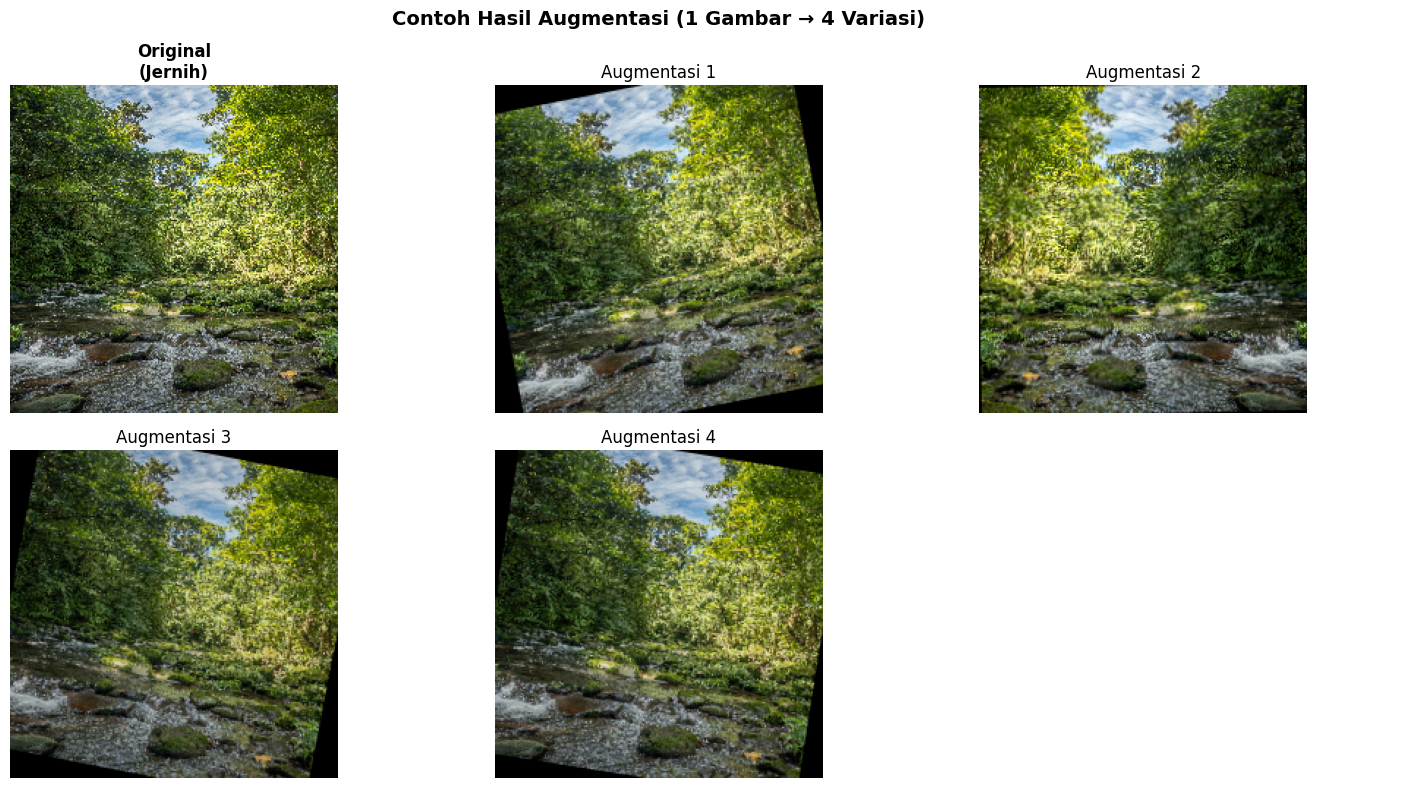

📊 Visualisasi disimpan: augmentation_example.png


In [9]:
# Visualisasi contoh augmentasi: 1 gambar original → 4 hasil augmentasi
sample_img = X_train[0]
sample_label = y_train[0]
label_names = {0: 'Jernih', 1: 'Keruh'}

# Layout 2 baris: baris 1 = 3 gambar, baris 2 = 2 gambar
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Baris 1: Original + Augmentasi 1 + Augmentasi 2
axes[0, 0].imshow(sample_img)
axes[0, 0].set_title(f"Original\n({label_names[sample_label]})", fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

aug_images = [augment_image(sample_img) for _ in range(4)]

axes[0, 1].imshow(aug_images[0])
axes[0, 1].set_title("Augmentasi 1", fontsize=12)
axes[0, 1].axis('off')

axes[0, 2].imshow(aug_images[1])
axes[0, 2].set_title("Augmentasi 2", fontsize=12)
axes[0, 2].axis('off')

# Baris 2: Augmentasi 3 + Augmentasi 4 + kosong
axes[1, 0].imshow(aug_images[2])
axes[1, 0].set_title("Augmentasi 3", fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(aug_images[3])
axes[1, 1].set_title("Augmentasi 4", fontsize=12)
axes[1, 1].axis('off')

axes[1, 2].axis('off')  # Kosongkan cell terakhir

plt.suptitle("Contoh Hasil Augmentasi (1 Gambar → 4 Variasi)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_example.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"📊 Visualisasi disimpan: augmentation_example.png")

## Step 6: Save All Data

In [10]:
# Create output directory structure
output_path.mkdir(exist_ok=True)
for split in ['train', 'val', 'test']:
    (output_path / split).mkdir(exist_ok=True)

# Save ORIGINAL training set (no augmentation)
np.save(output_path / 'train' / 'images.npy', X_train_augmented)
np.save(output_path / 'train' / 'labels.npy', y_train_augmented)

# Save ORIGINAL validation set (no augmentation)
np.save(output_path / 'val' / 'images.npy', X_val)
np.save(output_path / 'val' / 'labels.npy', y_val)

# Save ORIGINAL test set (no augmentation)
np.save(output_path / 'test' / 'images.npy', X_test)
np.save(output_path / 'test' / 'labels.npy', y_test)

# Save metadata
metadata = {
    'description': 'Best practice: Split first, no augmentation applied',
    'original_images': len(image_paths),
    'train_images': X_train_augmented.shape[0],
    'train_images_original': X_train.shape[0],
    'train_augmentation_ratio': 1.0,
    'val_images': X_val.shape[0],
    'test_images': X_test.shape[0],
    'image_size': (224, 224),
    'num_classes': 2,
    'class_names': ['Clear (Jernih)', 'Turbid (Keruh)'],
    'class_distribution': {
        'train': {'clear': int(np.sum(y_train_augmented==0)), 'turbid': int(np.sum(y_train_augmented==1))},
        'val': {'clear': int(np.sum(y_val==0)), 'turbid': int(np.sum(y_val==1))},
        'test': {'clear': int(np.sum(y_test==0)), 'turbid': int(np.sum(y_test==1))}
    },
    'split_ratio': '70/15/15',
    'preprocessing': 'Resized to 224x224, normalized to [0, 1]',
    'augmentation_applied_to': 'none',
    'augmentation_techniques': []
}

with open(output_path / 'metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✅ All data saved successfully!")
print(f"\nOutput directory: {output_path}")
print(f"\nDataset Summary:")
print(json.dumps(metadata, indent=2))

✅ All data saved successfully!

Output directory: data_processed_original_only

Dataset Summary:
{
  "description": "Best practice: Split first, no augmentation applied",
  "original_images": 807,
  "train_images": 553,
  "train_images_original": 553,
  "train_augmentation_ratio": 1.0,
  "val_images": 118,
  "test_images": 119,
  "image_size": [
    224,
    224
  ],
  "num_classes": 2,
  "class_names": [
    "Clear (Jernih)",
    "Turbid (Keruh)"
  ],
  "class_distribution": {
    "train": {
      "clear": 336,
      "turbid": 217
    },
    "val": {
      "clear": 72,
      "turbid": 46
    },
    "test": {
      "clear": 72,
      "turbid": 47
    }
  },
  "split_ratio": "70/15/15",
  "preprocessing": "Resized to 224x224, normalized to [0, 1]",
  "augmentation_applied_to": "none",
  "augmentation_techniques": []
}


## Step 7: Verify Data Integrity

In [11]:
# Load and verify saved data
print("Verifying saved data...\n")

# Load train
X_train_loaded = np.load(output_path / 'train' / 'images.npy')
y_train_loaded = np.load(output_path / 'train' / 'labels.npy')
print(f"Train: {X_train_loaded.shape} | Labels: {y_train_loaded.shape}")
print(f"  Class distribution: Clear={np.sum(y_train_loaded==0)}, Turbid={np.sum(y_train_loaded==1)}")

# Load val
X_val_loaded = np.load(output_path / 'val' / 'images.npy')
y_val_loaded = np.load(output_path / 'val' / 'labels.npy')
print(f"\nVal: {X_val_loaded.shape} | Labels: {y_val_loaded.shape}")
print(f"  Class distribution: Clear={np.sum(y_val_loaded==0)}, Turbid={np.sum(y_val_loaded==1)}")

# Load test
X_test_loaded = np.load(output_path / 'test' / 'images.npy')
y_test_loaded = np.load(output_path / 'test' / 'labels.npy')
print(f"\nTest: {X_test_loaded.shape} | Labels: {y_test_loaded.shape}")
print(f"  Class distribution: Clear={np.sum(y_test_loaded==0)}, Turbid={np.sum(y_test_loaded==1)}")

print(f"\n✅ All data verified successfully!")
print(f"\n📌 IMPORTANT NOTES:")
print(f"   1. Training set has {X_train_loaded.shape[0]} ORIGINAL images (NO augmentation)")
print(f"   2. Validation set has {X_val_loaded.shape[0]} ORIGINAL images (NO augmentation)")
print(f"   3. Test set has {X_test_loaded.shape[0]} ORIGINAL images (NO augmentation)")
print(f"   4. No data leakage between splits")

Verifying saved data...

Train: (553, 224, 224, 3) | Labels: (553,)
  Class distribution: Clear=336, Turbid=217

Val: (118, 224, 224, 3) | Labels: (118,)
  Class distribution: Clear=72, Turbid=46

Test: (119, 224, 224, 3) | Labels: (119,)
  Class distribution: Clear=72, Turbid=47

✅ All data verified successfully!

📌 IMPORTANT NOTES:
   1. Training set has 553 ORIGINAL images (NO augmentation)
   2. Validation set has 118 ORIGINAL images (NO augmentation)
   3. Test set has 119 ORIGINAL images (NO augmentation)
   4. No data leakage between splits
